In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
import scienceplots
# Set style
# mpl.style.use('default')
# plt.style.use()
# plt.style.use([$STYLESHEETS])
plt.style.use([ 'science', 'no-latex'])
sns.set_palette("husl")

# Set figure parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 20
import matplotlib as mpl
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(mpl.colormaps["retro"])

In [155]:
plt.ion()

In [156]:
STATIC_POOL_DIR = "final_3_500/"
LEARN_POOL_DIR = "final_4_500/"

In [157]:
plotting_strategies = [
    0,1,7, 10, 11
]
title = "Static vs Learning (Utility)"

In [158]:
def load_data(pool_dir):
    # Get all strategy directories
    strategy_dirs = [d for d in pool_dir.iterdir() if d.is_dir() and not d.name.startswith('analysis')]
    strategy_dirs = sorted(strategy_dirs, key=lambda x: int(x.name.split('_')[0]))

    print(f"Found {len(strategy_dirs)} strategy directories:")
    for d in strategy_dirs:
        print(f"  {d.name}")

    # Get noise levels from one directory
    sample_rep_dir = strategy_dirs[0] / 'repetition_0'
    csv_files = [f for f in sample_rep_dir.iterdir() if f.suffix == '.csv']
    noise_levels = sorted([float(f.stem) for f in csv_files])
    print(f"\nNoise levels: {noise_levels}")

    # Number of repetitions
    rep_dirs = [d for d in strategy_dirs[0].iterdir() if d.name.startswith('repetition_')]
    n_repetitions = len(rep_dirs)
    print(f"Number of repetitions: {n_repetitions}")

    def load_tournament_data():
        """
        Load all tournament data from the final directory structure.
        Returns a comprehensive DataFrame with all results.
        """
        all_data = []
        
        for strategy_dir in strategy_dirs:
            strategy_id = int(strategy_dir.name.split('_')[0])
            strategy_name = '_'.join(strategy_dir.name.split('_')[1:])
            
            print(f"Loading data for {strategy_dir.name}...")
            
            for rep in range(n_repetitions):
                rep_dir = strategy_dir / f'repetition_{rep}'
                
                # Load player names from details.json
                details_file = rep_dir / 'details.json'
                if details_file.exists():
                    with open(details_file, 'r') as f:
                        details = json.load(f)
                        player_names = details['player_names']
                else:
                    player_names = None
                
                for noise_level in noise_levels:
                    csv_file = rep_dir / f'{noise_level}.csv'
                    
                    if csv_file.exists():
                        try:
                            df = pd.read_csv(csv_file)
                            
                            # Add metadata columns
                            df['strategy_id'] = strategy_id
                            df['strategy_name'] = strategy_name
                            df['testing_strategy'] = f"{strategy_id}_{strategy_name}"
                            df['noise_level'] = noise_level
                            df['repetition_id'] = rep

                            # calculate last N cc_rate 
                            actions = df['Actions'].values
                            
                            # Add player names if available
                            if player_names:
                                df['player_name_clean'] = df['Player index'].map(
                                    lambda x: player_names[x] if x < len(player_names) else f"Player_{x}"
                                )
                                df['opponent_name_clean'] = df['Opponent index'].map(
                                    lambda x: player_names[x] if x < len(player_names) else f"Player_{x}"
                                )
                            
                            all_data.append(df)
                            
                        except Exception as e:
                            print(f"Error loading {csv_file}: {e}")
        
        # Combine all data
        full_df = pd.concat(all_data, ignore_index=True)
        print(f"\nLoaded {len(full_df)} total interactions")
        
        return full_df
    tournament_data = load_tournament_data()
    return tournament_data

In [159]:
static_tournament_results = load_data(Path(STATIC_POOL_DIR))
static_tournament_results.head()

Found 12 strategy directories:
  0_DBS
  1_RiskyQLearner
  2_APavlov2011
  3_ContriteTitForTat
  4_StochasticWSLS
  5_Cooperator
  6_Defector
  7_JaxFiveStateAgent
  8_JaxFiveStateAgentDecay
  9_JaxFiveStateAgentNoisy
  10_JaxFiveStateAgentUtility
  11_JaxFiveStateAgent

Noise levels: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Number of repetitions: 5
Loading data for 0_DBS...
Loading data for 1_RiskyQLearner...
Loading data for 2_APavlov2011...
Loading data for 3_ContriteTitForTat...
Loading data for 4_StochasticWSLS...
Loading data for 5_Cooperator...
Loading data for 6_Defector...
Loading data for 7_JaxFiveStateAgent...
Loading data for 8_JaxFiveStateAgentDecay...
Loading data for 9_JaxFiveStateAgentNoisy...
Loading data for 10_JaxFiveStateAgentUtility...
Loading data for 11_JaxFiveStateAgent...

Loaded 79200 total interactions


,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,DD to D count,Good partner,Intended Actions,strategy_id,strategy_name,testing_strategy,noise_level,repetition_id,player_name_clean,opponent_name_clean
0,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
1,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
2,1,0,1,0,"DBS: 0.75, 3, 4, 3, 5",Alternator,CCCCCCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDC...,1244,-15,500,...,0,1,CCCCCCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Alternator
3,1,1,0,0,Alternator,"DBS: 0.75, 3, 4, 3, 5",CDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCD...,1259,15,500,...,0,0,CDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCD...,0,DBS,0_DBS,0.0,0,Alternator,"DBS: 0.75, 3, 4, 3, 5"
4,2,0,2,0,"DBS: 0.75, 3, 4, 3, 5",Anti Tit For Tat,CCCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,2474,2450,500,...,1,0,CCCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Anti Tit For Tat


In [160]:
learn_tournament_results = load_data(Path(LEARN_POOL_DIR))
learn_tournament_results.head()

Found 12 strategy directories:
  0_DBS
  1_RiskyQLearner
  2_APavlov2011
  3_ContriteTitForTat
  4_StochasticWSLS
  5_Cooperator
  6_Defector
  7_JaxFiveStateAgent
  8_JaxFiveStateAgentDecay
  9_JaxFiveStateAgentNoisy
  10_JaxFiveStateAgentUtility
  11_JaxFiveStateAgent

Noise levels: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Number of repetitions: 5
Loading data for 0_DBS...
Loading data for 1_RiskyQLearner...
Loading data for 2_APavlov2011...
Loading data for 3_ContriteTitForTat...
Loading data for 4_StochasticWSLS...
Loading data for 5_Cooperator...
Loading data for 6_Defector...
Loading data for 7_JaxFiveStateAgent...
Loading data for 8_JaxFiveStateAgentDecay...
Loading data for 9_JaxFiveStateAgentNoisy...
Loading data for 10_JaxFiveStateAgentUtility...
Loading data for 11_JaxFiveStateAgent...

Loaded 79200 total interactions


,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,DD to D count,Good partner,Intended Actions,strategy_id,strategy_name,testing_strategy,noise_level,repetition_id,player_name_clean,opponent_name_clean
0,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
1,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
2,1,0,1,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2006,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2006
3,1,1,0,0,Adaptive Pavlov 2006,"DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,Adaptive Pavlov 2006,"DBS: 0.75, 3, 4, 3, 5"
4,2,0,2,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2011,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2011


In [161]:
def calculate_average_scores(tournament_data):
    """
    Calculate average scores for each testing strategy across all repetitions and opponents.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # Calculate average scores per testing strategy, noise level, and opponent
    avg_scores = testing_performance.groupby([
        'testing_strategy', 'noise_level', 'Opponent index', 'opponent_name_clean'
    ]).agg({
        'Score': 'mean',
        'Score per turn': 'mean',
        'Win': 'mean',
        'Cooperation count': 'mean',
        'Turns': 'mean'
    }).reset_index()
    
    # Calculate overall average across all opponents for each testing strategy and noise level
    overall_avg = testing_performance.groupby([
        'testing_strategy', 'noise_level'
    ]).agg({
        'Score': 'mean',
        'Score per turn': 'mean', 
        'Win': 'mean',
        'Cooperation count': 'mean'
    }).reset_index()
    
    return avg_scores, overall_avg


In [162]:
avg_scores_detailed, avg_scores_overall = calculate_average_scores(
    static_tournament_results
)

print("Average scores calculated!")
print(f"Detailed averages shape: {avg_scores_detailed.shape}")
print(f"Overall averages shape: {avg_scores_overall.shape}")

Average scores calculated!
Detailed averages shape: (1320, 9)
Overall averages shape: (120, 6)


In [163]:
avg_scores_detailed, avg_scores_overall = calculate_average_scores(
    learn_tournament_results
)

print("Average scores calculated!")
print(f"Detailed averages shape: {avg_scores_detailed.shape}")
print(f"Overall averages shape: {avg_scores_overall.shape}")

Average scores calculated!
Detailed averages shape: (1320, 9)
Overall averages shape: (120, 6)


In [164]:
testing_performance = static_tournament_results[static_tournament_results['Player index'] == 0].copy()
testing_performance.head(50)

,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,DD to D count,Good partner,Intended Actions,strategy_id,strategy_name,testing_strategy,noise_level,repetition_id,player_name_clean,opponent_name_clean
0,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
1,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
2,1,0,1,0,"DBS: 0.75, 3, 4, 3, 5",Alternator,CCCCCCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDC...,1244,-15,500,...,0,1,CCCCCCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDC...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Alternator
4,2,0,2,0,"DBS: 0.75, 3, 4, 3, 5",Anti Tit For Tat,CCCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,2474,2450,500,...,1,0,CCCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Anti Tit For Tat
6,3,0,3,0,"DBS: 0.75, 3, 4, 3, 5",Bully,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,2476,2455,500,...,1,0,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Bully
8,4,0,4,0,"DBS: 0.75, 3, 4, 3, 5",Cooperator,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Cooperator
10,5,0,5,0,"DBS: 0.75, 3, 4, 3, 5",Cycler DC,CCCCCCCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCD...,1244,-15,500,...,0,1,CCCCCCCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCDCD...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Cycler DC
12,6,0,6,0,"DBS: 0.75, 3, 4, 3, 5",Defector,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,496,-20,500,...,495,1,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Defector
14,7,0,7,0,"DBS: 0.75, 3, 4, 3, 5",Suspicious Tit For Tat,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1497,-5,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Suspicious Tit For Tat
16,8,0,8,0,"DBS: 0.75, 3, 4, 3, 5",Tit For Tat,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,1500,0,500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.00,0,"DBS: 0.75, 3, 4, 3, 5",Tit For Tat


In [165]:
def calculate_average_scores_with_ci(tournament_data):
    """
    Calculate average scores for each testing strategy across all repetitions and opponents,
    including 95% confidence intervals.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # First, calculate the average score per turn for each repetition
    rep_avg_scores = testing_performance.groupby(
        ['testing_strategy', 'noise_level', 'repetition_id']
    )['Score per turn'].mean().reset_index()

    # Now, calculate the mean, std, and count over the repetitions
    
    def agg_with_ci(x):
        mean = x.mean()
        std = x.std(ddof=1) # Use ddof=1 for sample standard deviation
        n = x.count()
        if n > 1:
            # Calculate 95% confidence interval
            se = std / np.sqrt(n)
            # t-distribution critical value for 95% CI
            t_crit = stats.t.ppf(0.975, df=n-1)
            ci_lower = mean - t_crit * se
            ci_upper = mean + t_crit * se
        else:
            se = np.nan
            t_crit = np.nan
            ci_lower = mean
            ci_upper = mean
            
        return pd.Series({
            'mean_score': mean,
            'std_dev': std,
            'n_reps': n,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

    
    # The result of apply can sometimes be a stacked series. We unstack it.
    overall_avg_with_ci = rep_avg_scores.groupby(
        ['testing_strategy', 'noise_level']
    )['Score per turn'].apply(agg_with_ci).unstack().reset_index()
    
    return overall_avg_with_ci

def plot_score_vs_noise_with_ci(avg_scores_df, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    # Define linestyles and change every 5 lines
    linestyles = ['-', '--', ':', '-.']
    
    for i, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
        
        is_plotting_strategy = False
        for strat in plotting_strategies:
            if str(strategy)[:2].replace("_", "") == str(strat):
                is_plotting_strategy = True
                print(str(strategy)[:2].replace("_", ""))
                print(str(strat))
                break

        if not is_plotting_strategy:
            continue

        strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]
        if str(strategy).__contains__("Jax"):
            strategy = str(strategy).replace("JaxFiveStateAgent", "ActiveInference")
        strategy = strategy[2:]
        strategy = str(strategy).replace("RiskyQLearner", "Q-Learner")
        
        
        # Calculate the error size from the confidence interval for plt.errorbar
        y_error = strategy_data['mean_score'] - strategy_data['ci_lower']


        style = linestyles[(i // 5) % len(linestyles)]
        plt.errorbar(x=strategy_data['noise_level'], 
                     y=strategy_data['mean_score'], 
                     yerr=y_error,
                     label=strategy,
                     marker='o',
                     linestyle=style,
                     capsize=3, # Add caps to the error bars for visibility
                     )

    plt.title(f'Average Score per Turn vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('Average Score per Turn')
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1, 1), loc='upper right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # matplot2tikz.clean_figure()
    # matplot2tikz.save(f"final_4/{title}_ccrate_vs_noise.tex")
    # save_pgf(plt, f"final_4/{title}_ccrate_vs_noise.pgf")
    plt.tight_layout()
    plt.savefig(f"final_4/{title}_score_vs_noise.pdf")
    plt.savefig(f"final_4/{title}_score_vs_noise.png")
    plt.show()

In [166]:
# For static pool
static_scores_with_ci = calculate_average_scores_with_ci(static_tournament_results)
static_scores_with_ci.head(120)

,testing_strategy,noise_level,mean_score,std_dev,n_reps,se,ci_lower,ci_upper
0,0_DBS,0.00,3.233000,4.965068e-16,5.0,2.220446e-16,3.233000,3.233000
1,0_DBS,0.05,2.979200,1.353719e-02,5.0,6.054016e-03,2.962391,2.996009
2,0_DBS,0.10,2.804367,2.468395e-02,5.0,1.103900e-02,2.773717,2.835016
3,0_DBS,0.15,2.673767,1.498777e-02,5.0,6.702736e-03,2.655157,2.692376
4,0_DBS,0.20,2.578200,6.706769e-02,5.0,2.999358e-02,2.494924,2.661476
...,...,...,...,...,...,...,...,...
115,9_JaxFiveStateAgentNoisy,0.25,2.194167,1.793391e-02,5.0,8.020287e-03,2.171899,2.216435
116,9_JaxFiveStateAgentNoisy,0.30,2.214133,7.625250e-03,5.0,3.410116e-03,2.204665,2.223601
117,9_JaxFiveStateAgentNoisy,0.35,2.235233,1.211553e-02,5.0,5.418231e-03,2.220190,2.250277
118,9_JaxFiveStateAgentNoisy,0.40,2.249700,1.129245e-02,5.0,5.050138e-03,2.235679,2.263721


0
0
10
10
11
11
1
1
7
7


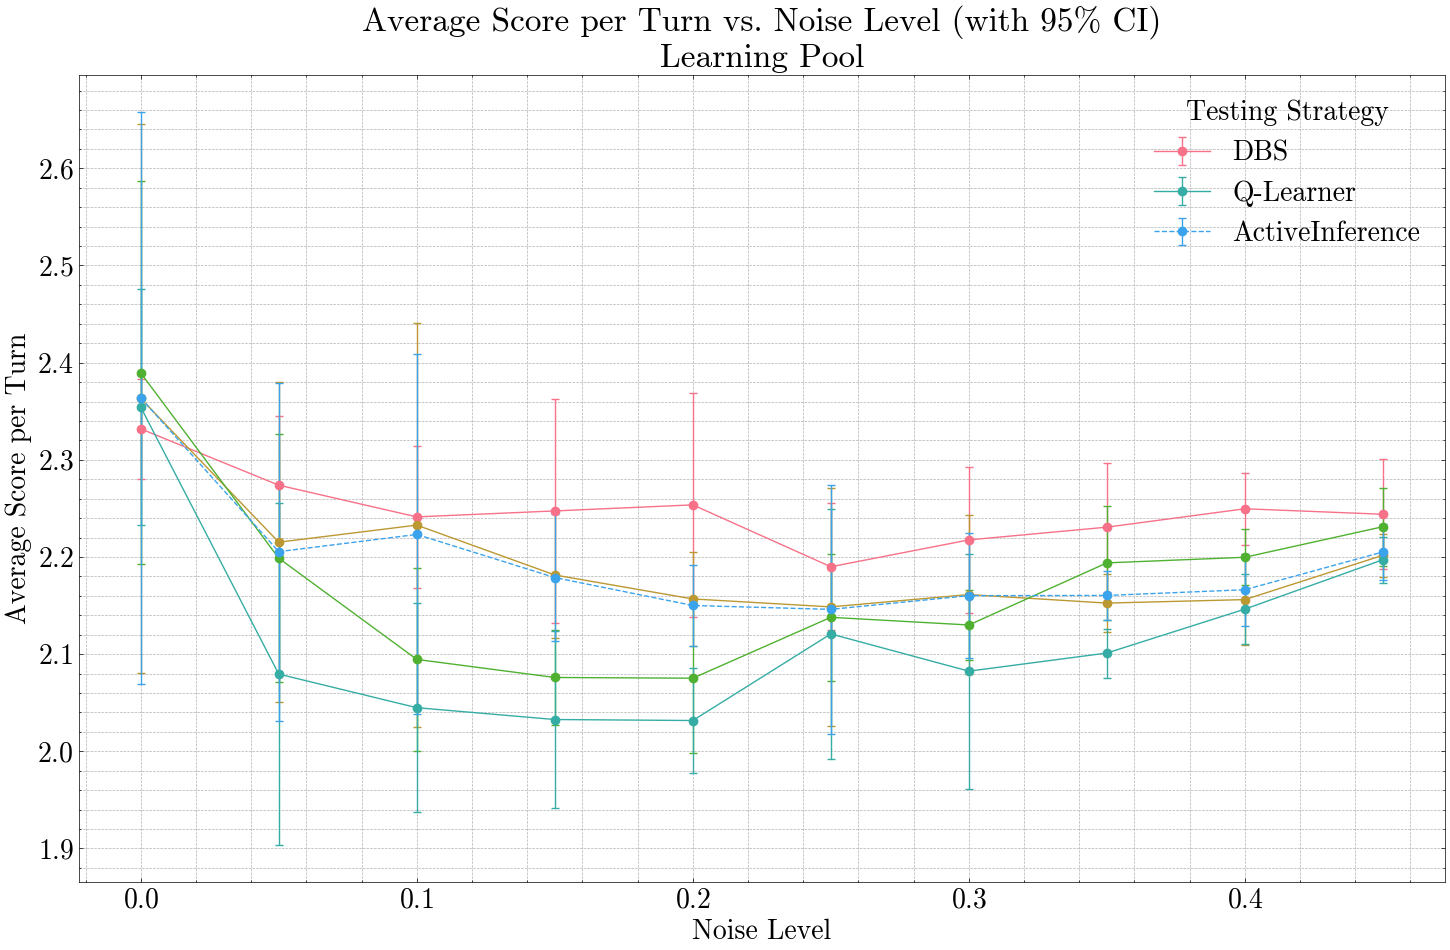

In [167]:
# For learning pool
learn_scores_with_ci = calculate_average_scores_with_ci(learn_tournament_results)
learn_scores_with_ci.to_csv("score_learning.csv")

plot_score_vs_noise_with_ci(learn_scores_with_ci, title="Learning Pool")

0
0
10
10
11
11
1
1
7
7
0
0
10
10
11
11
1
1
7
7


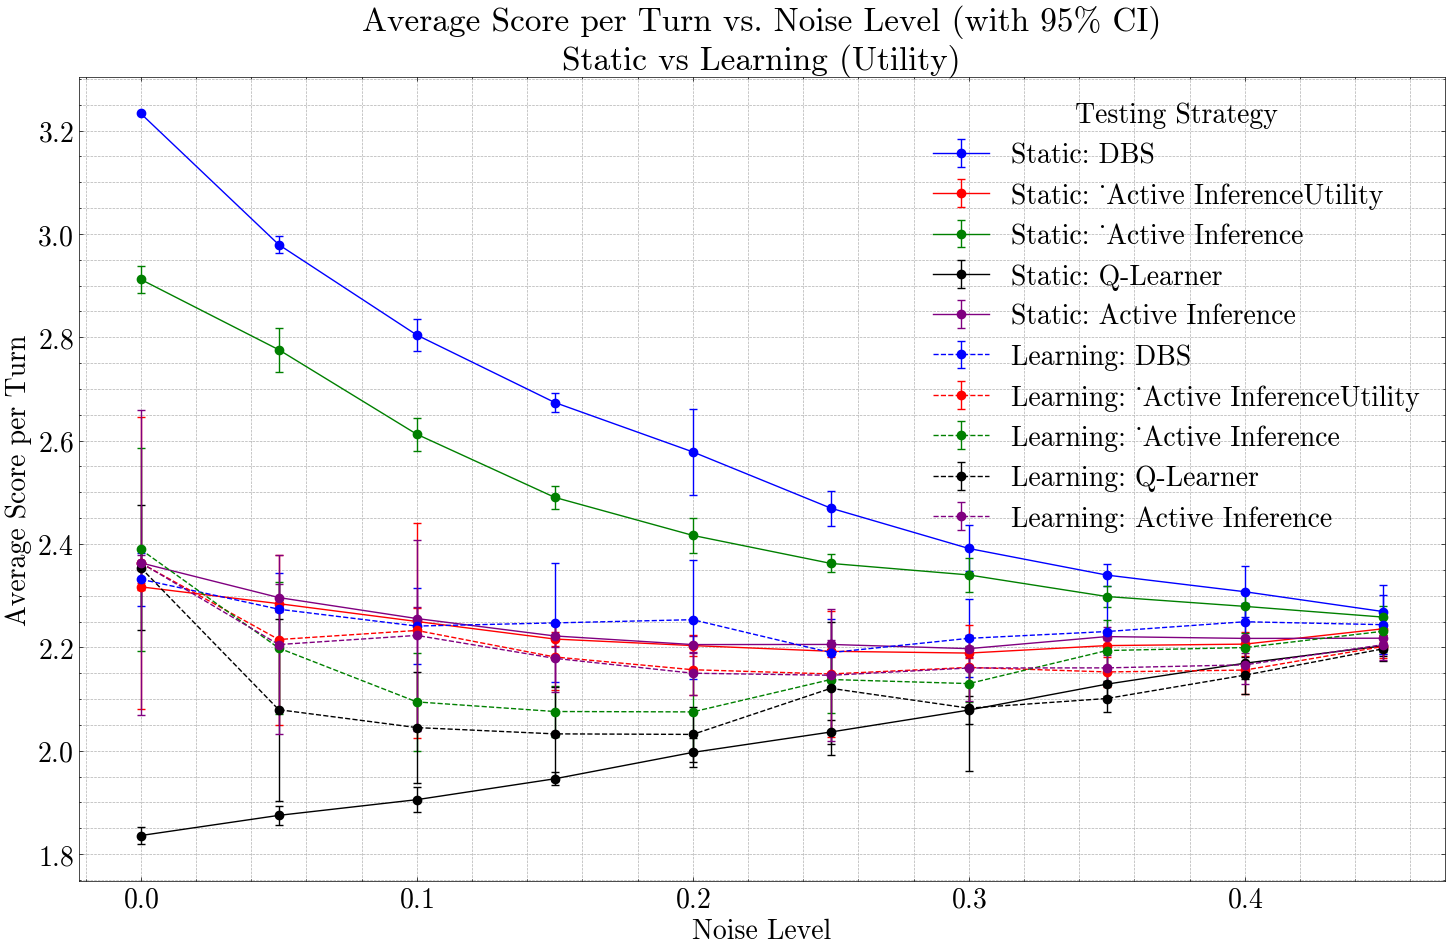

In [168]:
def plot_score_vs_noise_with_ci(avg_scores_df_static, avg_scores_df_learning, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    linestyles = ['-', '--']
    colors = ['b', 'r', 'g', 'k', 'purple', 'orange', 'brown', 'pink', 'gray', 'black']
    for i,avg_scores_df in enumerate([avg_scores_df_static, avg_scores_df_learning]):
        col_idx = 0
        for j, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
            
            is_plotting_strategy = False
            for strat in plotting_strategies:
                if str(strategy)[:2].replace("_", "") == str(strat):
                    is_plotting_strategy = True
                    print(str(strategy)[:2].replace("_", ""))
                    print(str(strat))
                    break

            if not is_plotting_strategy:
                continue

            strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]
            if str(strategy).__contains__("Jax"):
                strategy = str(strategy).replace("JaxFiveStateAgent", "Active Inference")
            strategy = strategy[2:]
            strategy = str(strategy).replace("RiskyQLearner", "Q-Learner")
            
            
            # Calculate the error size from the confidence interval for plt.errorbar
            y_error = strategy_data['mean_score'] - strategy_data['ci_lower']

            label = "Static" if i == 0 else "Learning"
            style = linestyles[(i) % 2]
            color = colors[col_idx]
            col_idx += 1
            plt.errorbar(x=strategy_data['noise_level'], 
                        y=strategy_data['mean_score'], 
                        yerr=y_error,
                        label=f"{label}: {strategy}",
                        marker='o',
                        linestyle=style,
                        capsize=3, # Add caps to the error bars for visibility
                        color=color,
                        )

    plt.title(f'Average Score per Turn vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('Average Score per Turn')
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1, 1), loc='upper right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(f"final_4/{title}_score_vs_noise.pdf")
    plt.savefig(f"final_4/{title}_score_vs_noise.png")
    plt.show()

plot_score_vs_noise_with_ci(static_scores_with_ci, learn_scores_with_ci, title=title)

In [169]:
def calculate_average_cc_rate_with_ci(tournament_data):
    """
    Calculate average scores for each testing strategy across all repetitions and opponents,
    including 95% confidence intervals.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # First, calculate the average score per turn for each repetition
    rep_avg_scores = testing_performance.groupby(
        ['testing_strategy', 'noise_level', 'repetition_id']
    )['CC count'].mean().reset_index()

    # Now, calculate the mean, std, and count over the repetitions
    
    def agg_with_ci(x):
        x = x / 1500
        mean = x.mean()
        std = x.std(ddof=1) # Use ddof=1 for sample standard deviation
        n = x.count()
        if n > 1:
            # Calculate 95% confidence interval
            se = std / np.sqrt(n)
            # t-distribution critical value for 95% CI
            t_crit = stats.t.ppf(0.975, df=n-1)
            ci_lower = mean - t_crit * se
            ci_upper = mean + t_crit * se
        else:
            se = np.nan
            t_crit = np.nan
            ci_lower = mean
            ci_upper = mean
            
        return pd.Series({
            'mean_score': mean,
            'std_dev': std,
            'n_reps': n,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

    
    # The result of apply can sometimes be a stacked series. We unstack it.
    overall_avg_with_ci = rep_avg_scores.groupby(
        ['testing_strategy', 'noise_level']
    )['CC count'].apply(agg_with_ci).unstack().reset_index()
    
    return overall_avg_with_ci

def plot_cc_rate_vs_noise_with_ci(avg_scores_df, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    # Define linestyles and change every 5 lines
    linestyles = ['-', '--', ':', '-.']
    
    for i, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
        is_plotting_strategy = False
        for strat in plotting_strategies:
            if str(strategy)[:2].replace("_", "") == str(strat):
                is_plotting_strategy = True
                break

        if not is_plotting_strategy:
            continue

        strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]

        if str(strategy).__contains__("Jax"):
            strategy = str(strategy).replace("JaxFiveStateAgent", "ActiveInference")
        strategy = strategy[2:]
        strategy = str(strategy).replace("RiskyQLearner", "Q-Learner")
        
        # Calculate the error size from the confidence interval for plt.errorbar
        y_error = strategy_data['mean_score'] - strategy_data['ci_lower']
   
        
        style = linestyles[(i // 5) % len(linestyles)]
        plt.errorbar(x=strategy_data['noise_level'], 
                     y=strategy_data['mean_score'], 
                     yerr=y_error,
                     label=strategy,
                     marker='o',
                     linestyle=style,
                     capsize=3, # Add caps to the error bars for visibility
                     )

    plt.title(f'Average Mutual Cooperation Rate vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('Average Mutual Cooperation Rate')
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1, 1), loc='upper right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # matplot2tikz.clean_figure()
    # matplot2tikz.save(f"final_4/{title}_ccrate_vs_noise.tex")
    # save_pgf(plt, f"final_4/{title}_ccrate_vs_noise.pgf")
    plt.tight_layout()
    plt.savefig(f"final_4/{title}_ccrate_vs_noise.pdf")
    plt.savefig(f"final_4/{title}_ccrate_vs_noise.png")
    plt.show()



In [170]:
# For static pool
static_cc_with_ci = calculate_average_cc_rate_with_ci(static_tournament_results)
static_cc_with_ci

,testing_strategy,noise_level,mean_score,std_dev,n_reps,se,ci_lower,ci_upper
0,0_DBS,0.00,0.167222,0.000000,5.0,0.000000,0.167222,0.167222
1,0_DBS,0.05,0.086489,0.002036,5.0,0.000910,0.083961,0.089017
2,0_DBS,0.10,0.076711,0.001338,5.0,0.000598,0.075050,0.078372
3,0_DBS,0.15,0.071711,0.001452,5.0,0.000649,0.069909,0.073513
4,0_DBS,0.20,0.075344,0.008113,5.0,0.003628,0.065271,0.085418
...,...,...,...,...,...,...,...,...
115,9_JaxFiveStateAgentNoisy,0.25,0.097511,0.003002,5.0,0.001342,0.093784,0.101238
116,9_JaxFiveStateAgentNoisy,0.30,0.091811,0.001793,5.0,0.000802,0.089585,0.094037
117,9_JaxFiveStateAgentNoisy,0.35,0.088256,0.001706,5.0,0.000763,0.086137,0.090374
118,9_JaxFiveStateAgentNoisy,0.40,0.085867,0.001823,5.0,0.000815,0.083603,0.088131


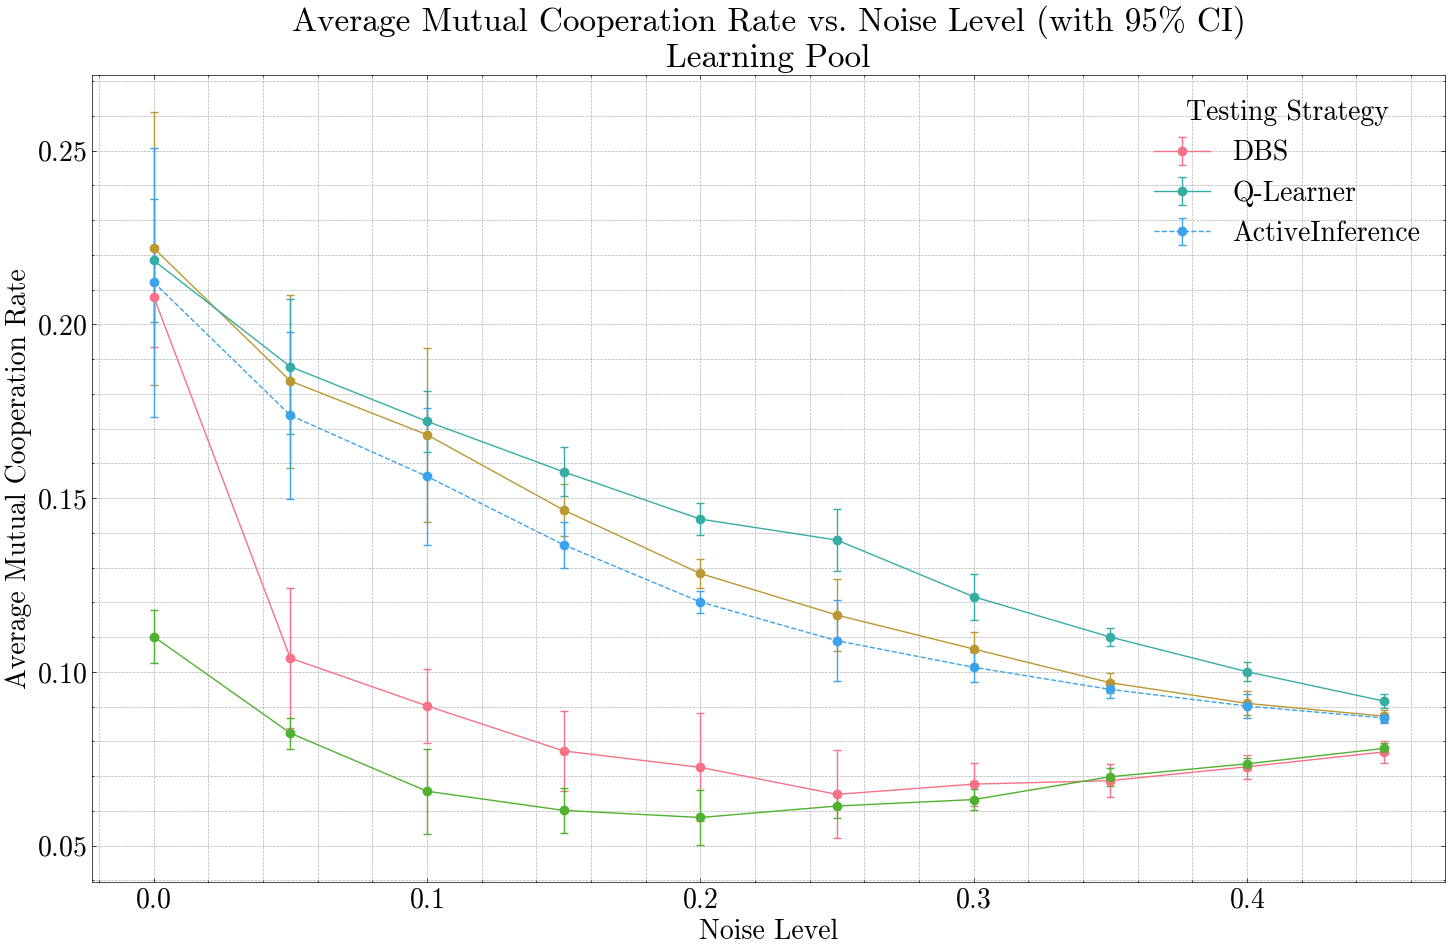

In [171]:
# For learning pool
learn_cc_with_ci = calculate_average_cc_rate_with_ci(learn_tournament_results)
learn_cc_with_ci.to_csv("cc_rate_learning.csv")
plot_cc_rate_vs_noise_with_ci(learn_cc_with_ci, title="Learning Pool")

0
0
10
10
11
11
1
1
7
7
0
0
10
10
11
11
1
1
7
7


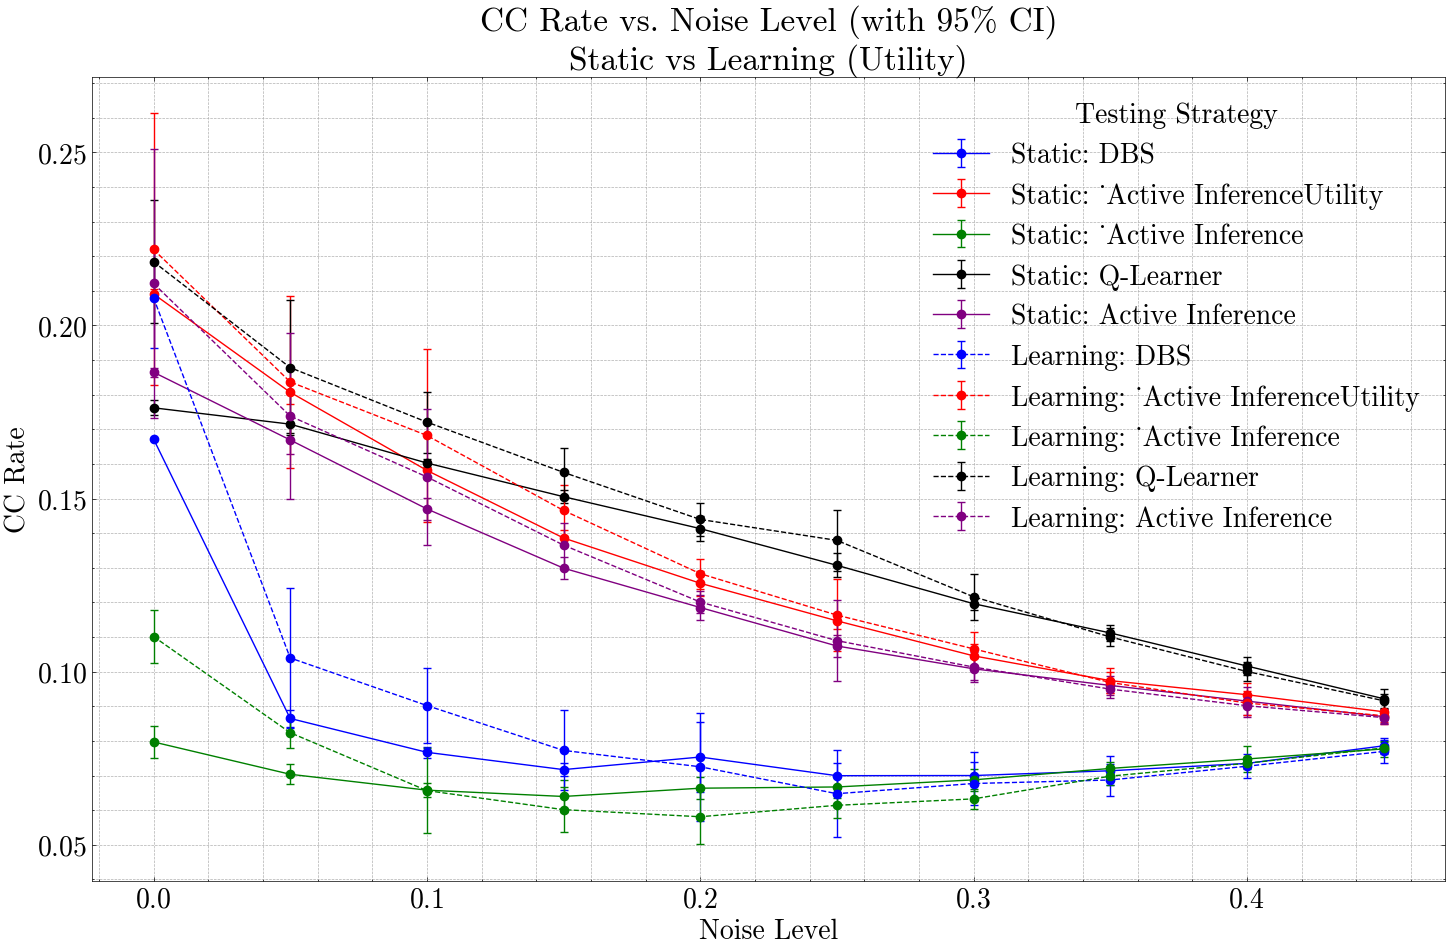

In [172]:
def plot_cc_vs_noise_with_ci(avg_scores_df_static, avg_scores_df_learning, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    linestyles = ['-', '--']
    colors = ['b', 'r', 'g', 'k', 'purple', 'orange', 'brown', 'pink', 'gray', 'black']
    for i,avg_scores_df in enumerate([avg_scores_df_static, avg_scores_df_learning]):
        col_idx = 0
        for j, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
            
            is_plotting_strategy = False
            for strat in plotting_strategies:
                if str(strategy)[:2].replace("_", "") == str(strat):
                    is_plotting_strategy = True
                    print(str(strategy)[:2].replace("_", ""))
                    print(str(strat))
                    break

            if not is_plotting_strategy:
                continue

            strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]
            if str(strategy).__contains__("Jax"):
                strategy = str(strategy).replace("JaxFiveStateAgent", "Active Inference")
            strategy = strategy[2:]
            strategy = str(strategy).replace("RiskyQLearner", "Q-Learner")
            
            
            # Calculate the error size from the confidence interval for plt.errorbar
            y_error = strategy_data['mean_score'] - strategy_data['ci_lower']

            label = "Static" if i == 0 else "Learning"
            style = linestyles[(i) % 2]
            color = colors[col_idx]
            col_idx += 1
            plt.errorbar(x=strategy_data['noise_level'], 
                        y=strategy_data['mean_score'], 
                        yerr=y_error,
                        label=f"{label}: {strategy}",
                        marker='o',
                        linestyle=style,
                        capsize=3, # Add caps to the error bars for visibility
                        color=color,
                        )

    plt.title(f'CC Rate vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('CC Rate')
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1, 1), loc='upper right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(f"final_4/{title}_cc_vs_noise.pdf")
    plt.savefig(f"final_4/{title}_cc_vs_noise.png")
    plt.show()

plot_cc_vs_noise_with_ci(static_cc_with_ci, learn_cc_with_ci, title=title)

In [173]:
def calculate_average_cd_rate_with_ci(tournament_data):
    """
    Calculate average scores for each testing strategy across all repetitions and opponents,
    including 95% confidence intervals.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # First, calculate the average score per turn for each repetition
    rep_avg_scores = testing_performance.groupby(
        ['testing_strategy', 'noise_level', 'repetition_id']
    )['CD count'].mean().reset_index()

    # Now, calculate the mean, std, and count over the repetitions
    
    def agg_with_ci(x):
        x = x / 1500
        mean = x.mean()
        std = x.std(ddof=1) # Use ddof=1 for sample standard deviation
        n = x.count()
        if n > 1:
            # Calculate 95% confidence interval
            se = std / np.sqrt(n)
            # t-distribution critical value for 95% CI
            t_crit = stats.t.ppf(0.975, df=n-1)
            ci_lower = mean - t_crit * se
            ci_upper = mean + t_crit * se
        else:
            se = np.nan
            t_crit = np.nan
            ci_lower = mean
            ci_upper = mean
            
        return pd.Series({
            'mean_score': mean,
            'std_dev': std,
            'n_reps': n,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

    
    # The result of apply can sometimes be a stacked series. We unstack it.
    overall_avg_with_ci = rep_avg_scores.groupby(
        ['testing_strategy', 'noise_level']
    )['CD count'].apply(agg_with_ci).unstack().reset_index()
    
    return overall_avg_with_ci

def plot_cd_rate_vs_noise_with_ci(avg_scores_df, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    # Define linestyles and change every 5 lines
    linestyles = ['-', '--', ':', '-.']
    
    for i, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
        is_plotting_strategy = False
        for strat in plotting_strategies:
            if str(strategy)[:2].replace("_", "") == str(strat):
                is_plotting_strategy = True
                break

        if not is_plotting_strategy:
            continue

        strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]

        if str(strategy).__contains__("Jax"):
            strategy = str(strategy).replace("JaxFiveStateAgent", "ActiveInference")
        strategy = strategy[2:]
        strategy = str(strategy).replace("RiskyQLearner", "Q-Learner")
        
        # Calculate the error size from the confidence interval for plt.errorbar
        y_error = strategy_data['mean_score'] - strategy_data['ci_lower']


        style = linestyles[(i // 5) % len(linestyles)]
        plt.errorbar(x=strategy_data['noise_level'], 
                     y=strategy_data['mean_score'], 
                     yerr=y_error,
                     label=strategy,
                     marker='o',
                     linestyle=style,
                     capsize=3, # Add caps to the error bars for visibility
                     )

    plt.title(f'Average CD Rate vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('Average CD Rate')
    plt.ylim(0, 0.5)
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1, 1), loc='upper right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    # matplot2tikz.clean_figure()
    # matplot2tikz.save(f"final_4/{title}_cdrate_vs_noise.tex")
    # save_pgf(plt, f"final_4/{title}_cdrate_vs_noise.pgf")
    plt.savefig(f"final_4/{title}_cdrate_vs_noise.pdf")
    plt.savefig(f"final_4/{title}_cdrate_vs_noise.png")
    plt.tight_layout()
    plt.show()


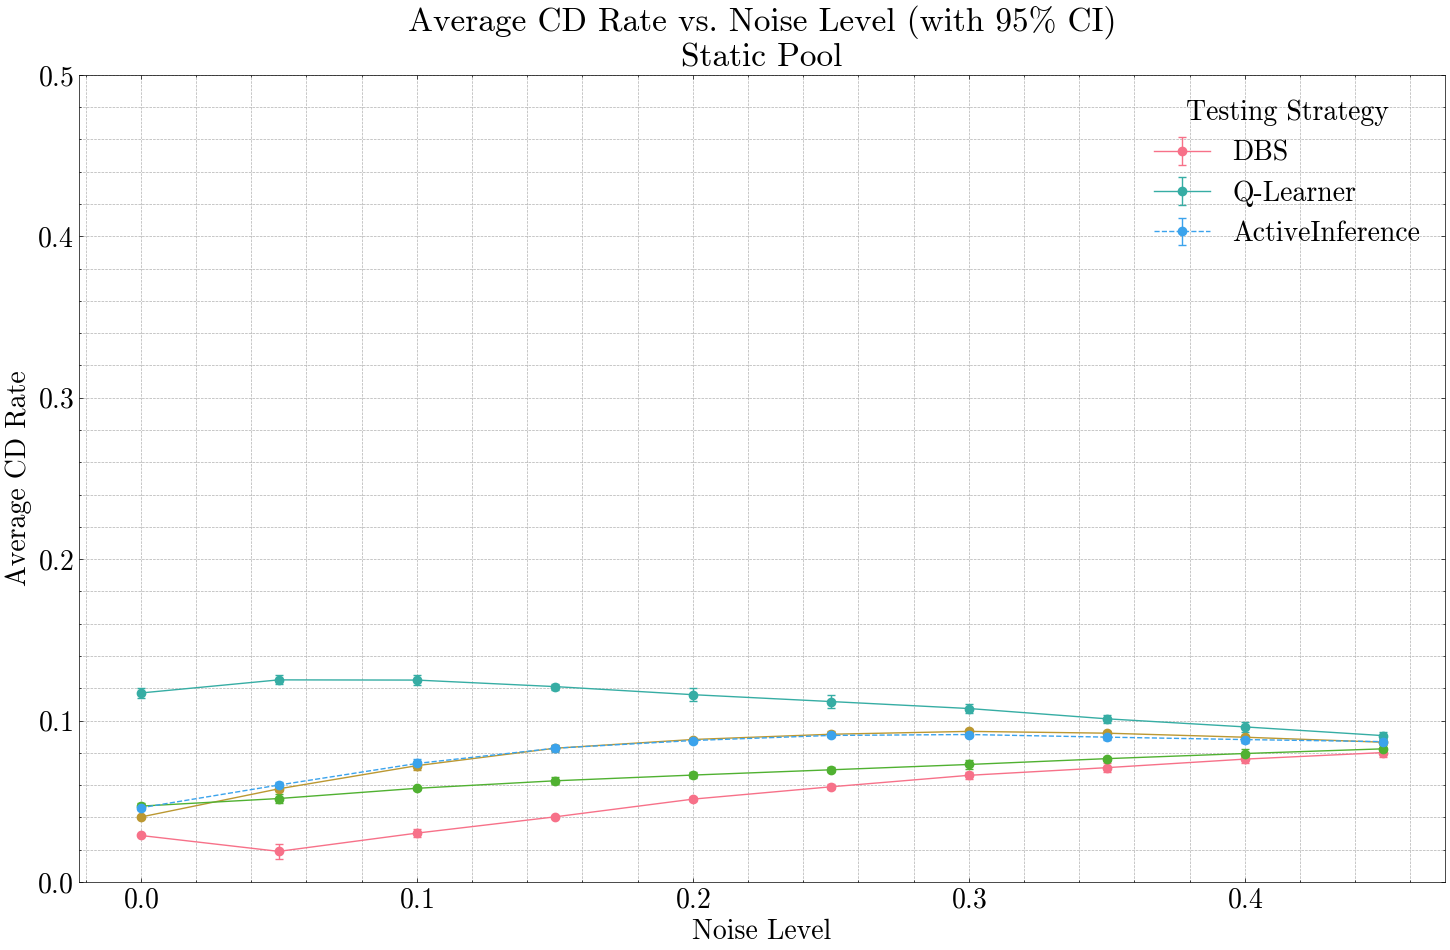

In [174]:
# For learning pool
static_cd_with_ci = calculate_average_cd_rate_with_ci(static_tournament_results)
static_cd_with_ci.to_csv("cd_rate_static.csv")
plot_cd_rate_vs_noise_with_ci(static_cd_with_ci, title="Static Pool")

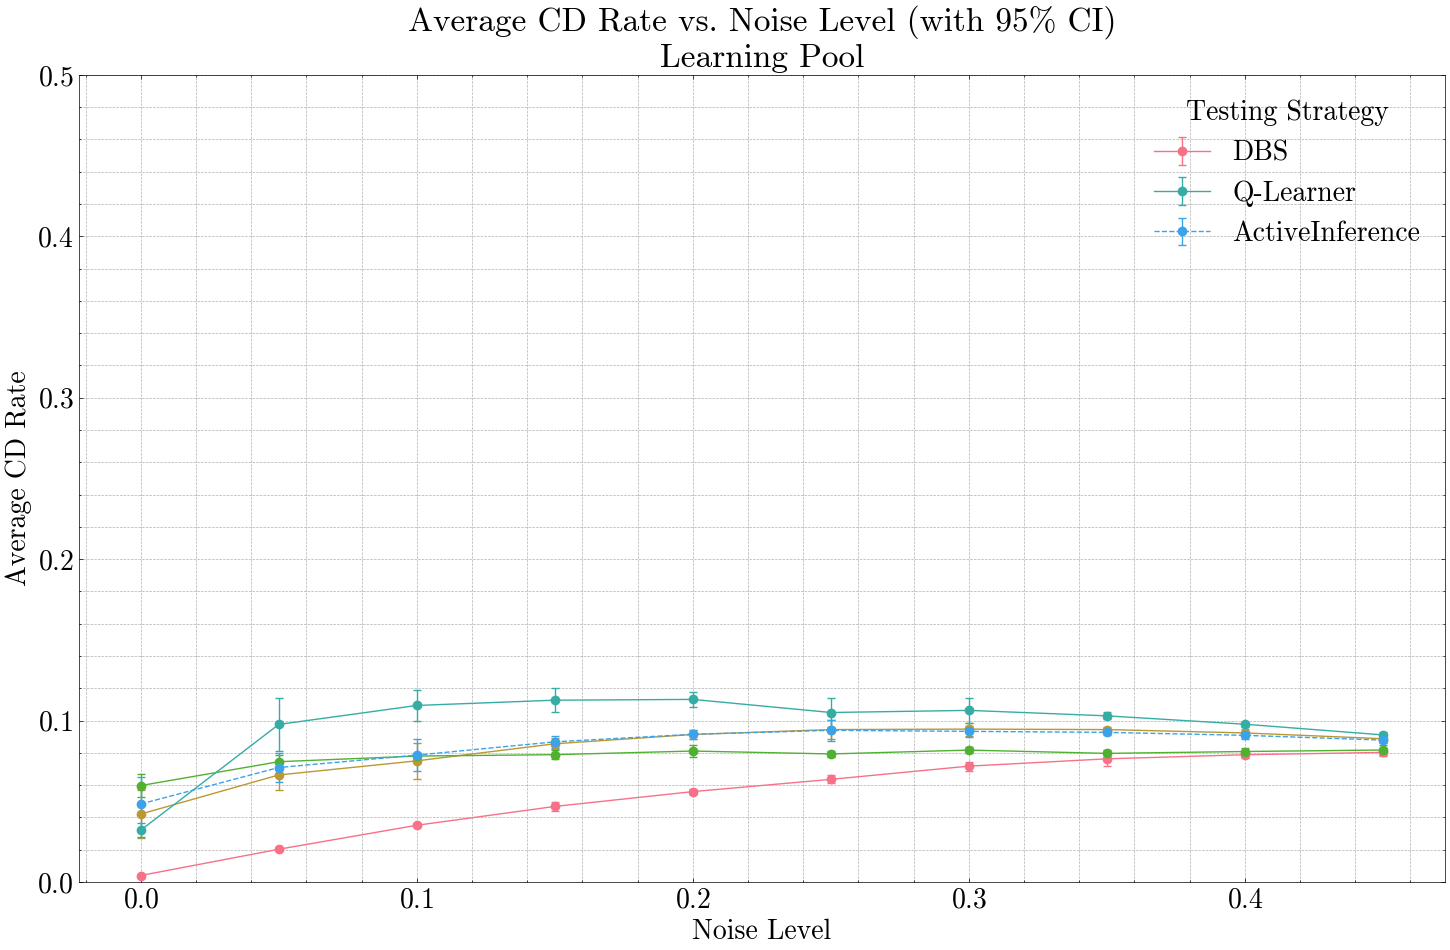

In [175]:
# For learning pool
learn_cd_with_ci = calculate_average_cd_rate_with_ci(learn_tournament_results)
learn_cd_with_ci.to_csv("cd_rate_learning.csv")
plot_cd_rate_vs_noise_with_ci(learn_cd_with_ci, title="Learning Pool")

0
0
10
10
11
11
1
1
7
7
0
0
10
10
11
11
1
1
7
7


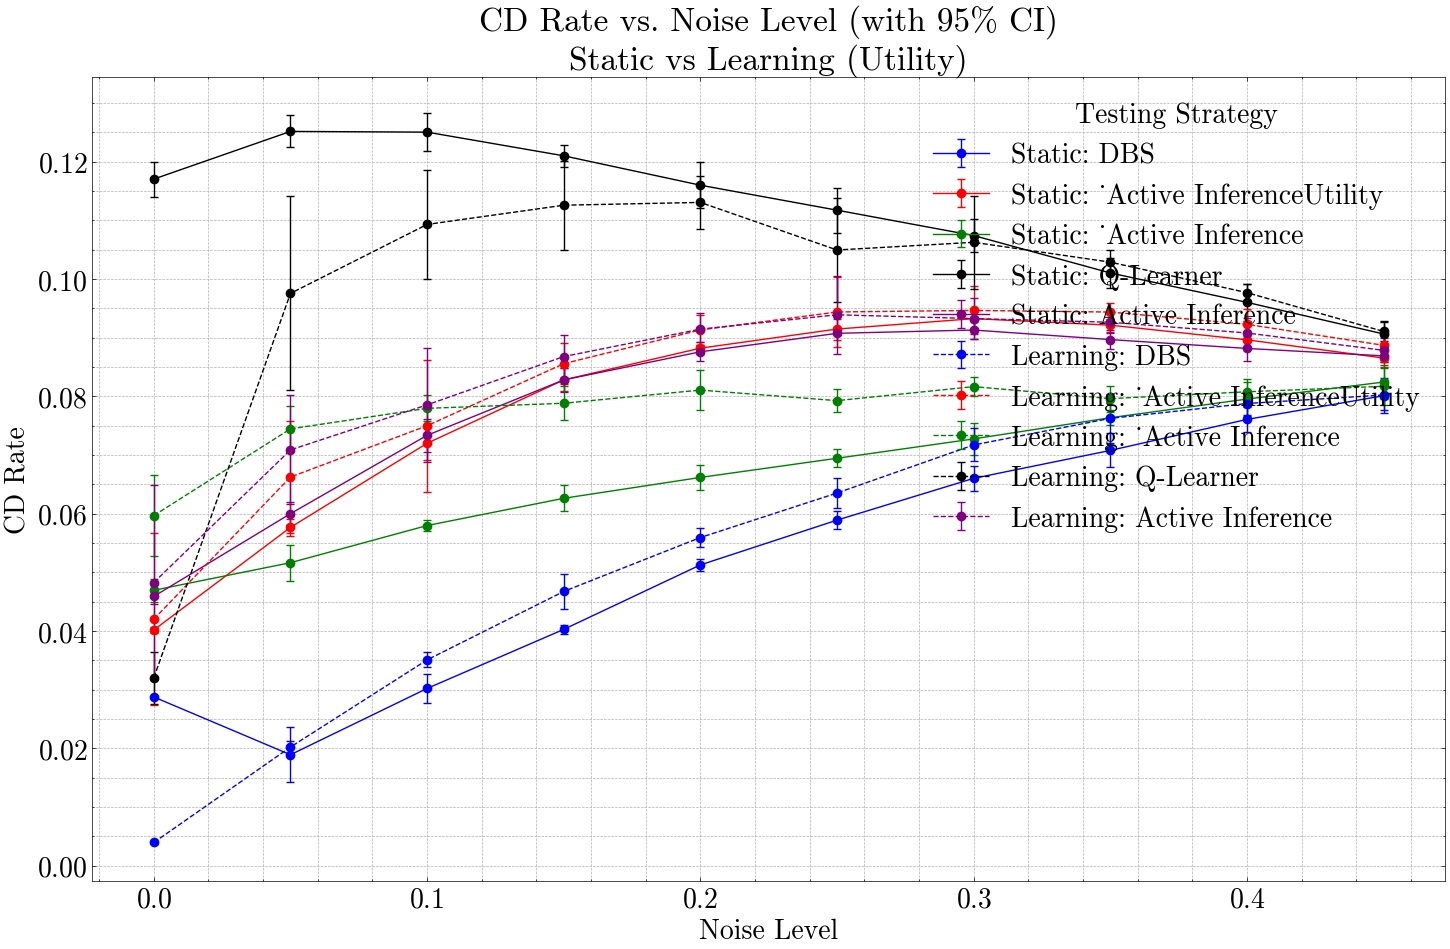

In [176]:
def plot_cd_vs_noise_with_ci(avg_scores_df_static, avg_scores_df_learning, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    linestyles = ['-', '--']
    colors = ['b', 'r', 'g', 'k', 'purple', 'orange', 'brown', 'pink', 'gray', 'black']
    for i,avg_scores_df in enumerate([avg_scores_df_static, avg_scores_df_learning]):
        col_idx = 0
        for j, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
            
            is_plotting_strategy = False
            for strat in plotting_strategies:
                if str(strategy)[:2].replace("_", "") == str(strat):
                    is_plotting_strategy = True
                    print(str(strategy)[:2].replace("_", ""))
                    print(str(strat))
                    break

            if not is_plotting_strategy:
                continue

            strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]
            if str(strategy).__contains__("Jax"):
                strategy = str(strategy).replace("JaxFiveStateAgent", "Active Inference")
            strategy = strategy[2:]
            strategy = str(strategy).replace("RiskyQLearner", "Q-Learner")
            
            
            # Calculate the error size from the confidence interval for plt.errorbar
            y_error = strategy_data['mean_score'] - strategy_data['ci_lower']

            label = "Static" if i == 0 else "Learning"
            style = linestyles[(i) % 2]
            color = colors[col_idx]
            col_idx += 1
            plt.errorbar(x=strategy_data['noise_level'], 
                        y=strategy_data['mean_score'], 
                        yerr=y_error,
                        label=f"{label}: {strategy}",
                        marker='o',
                        linestyle=style,
                        capsize=3, # Add caps to the error bars for visibility
                        color=color,
                        )

    plt.title(f'CD Rate vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('CD Rate')
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1, 1), loc='upper right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(f"final_4/{title}_cd_vs_noise.pdf")
    plt.savefig(f"final_4/{title}_cd_vs_noise.png")
    plt.show()

plot_cd_vs_noise_with_ci(static_cd_with_ci, learn_cd_with_ci, title=title)